# 1. Data Cleaning & Feature Engineering

**Overview & Workflow Sketch**

**Step 1: Standardizing Categorical Labels**
* **Action:** Clean inconsistent entries in the `Item_Fat_Content` column. Map 'LF' and 'low fat' to **'Low Fat'**, and 'reg' to **'Regular'**.
* **Reasoning:** Machine learning models treat 'LF' and 'Low Fat' as entirely different categories. Standardizing them prevents the model from splitting its learning capacity across duplicate categories, thereby avoiding the "dummy variable trap" later during encoding.

**Step 2: Fixing Business Logic Errors**
* **Action:** Identify Non-Consumable items (where `Item_Identifier` starts with 'NC') and change their `Item_Fat_Content` to **'Non-Edible'**.
* **Reasoning:** During EDA, we discovered a logical flaw where items like household goods were labeled as 'Low Fat'. Correcting this separates food items from non-food items, giving the model a more accurate representation of the physical world.

**Step 3: Handling Placeholders (The 0.0 Issue)**
* **Action:** Replace `0.0` values in `Item_Visibility` with `NaN`.
* **Reasoning:** A product physically placed in a store cannot have 0% visibility. The `0.0` is likely a system default for missing data. Treating it as a valid number would severely skew the mean calculation later. We must convert it to `NaN` first to impute it properly.

**Step 4: Imputation for Missing Values**
Instead of using global averages (which introduces high bias), we will use *Grouped Imputation*:
1.  **`Item_Weight` (17.17% missing):** Imputed using the **Mean** weight of the corresponding `Item_Identifier` because the same product code has the exact same physical weight.
2.  **`Item_Visibility` (~6% missing after Step 3):** Imputed using the **Mean** visibility of the corresponding `Item_Identifier` because The same product is likely allocated similar shelf space across different stores.
3.  **`Outlet_Size` (28.28% missing):** Replaced missing values with a new distinct category, **'Unknown'** because since nearly a third of the data is missing, imputing via Mode would introduce severe bias and artificially distort the actual distribution. Treating "missingness" as its own category preserves data integrity and allows the machine learning model to capture any potential hidden patterns associated with unrecorded store sizes.

**Step 5: Feature Engineering (Outlet Age)**
* **Action**: Create a new feature `Outlet_Years` by subtracting `Outlet_Establishment_Year` from the reference year **2013**.

* **Reasoning**: Raw years like '1985' or '2009' do not directly represent a store's maturity to a machine learning model. Converting them into "**Years of Operation**" provides a more meaningful numerical feature that correlates store experience and brand trust with sales performance.

**Step 6: Dropping Irrelevant Features**
* **Action**: Remove `Item_Identifier`, `Outlet_Identifier` and the original `Outlet_Establishment_Year` column.

* **Reasoning**: 
  * `Item_Identifier` contains over **1,500 unique IDs**, which introduces high cardinality and noise, leading to overfitting. 
  * `Outlet_Identifier` is a store-specific ID that prevents the model from generalizing to new, unseen branches. Furthermore, its inherent information is already fully captured by existing features (`Outlet_Type`, `Outlet_Size`, `Outlet_Location_Type`), making it a potential source of multicollinearity.
  * `Outlet_Establishment_Year` is now redundant because its predictive information has been fully captured in the new `Outlet_Years` feature.

## 1.1 Standardizing Categorical Labels
Unifying inconsistent entries in the `Item_Fat_Content` column ('LF', 'low fat' $\rightarrow$ 'Low Fat'; 'reg' $\rightarrow$ 'Regular') to ensure clean and uniform categories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import itertools

In [2]:
# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load the dataset
file_path = '../data/raw/big_mart_sales.csv' 
df = pd.read_csv(file_path)
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [3]:
print("--- Before Processing: Item_Fat_Content ---")
print(df['Item_Fat_Content'].value_counts())
print("-" * 40)

# Standardize inconsistent categorical labels
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

print("\n--- After Processing: Item_Fat_Content ---")
print(df['Item_Fat_Content'].value_counts())

--- Before Processing: Item_Fat_Content ---
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
----------------------------------------

--- After Processing: Item_Fat_Content ---
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


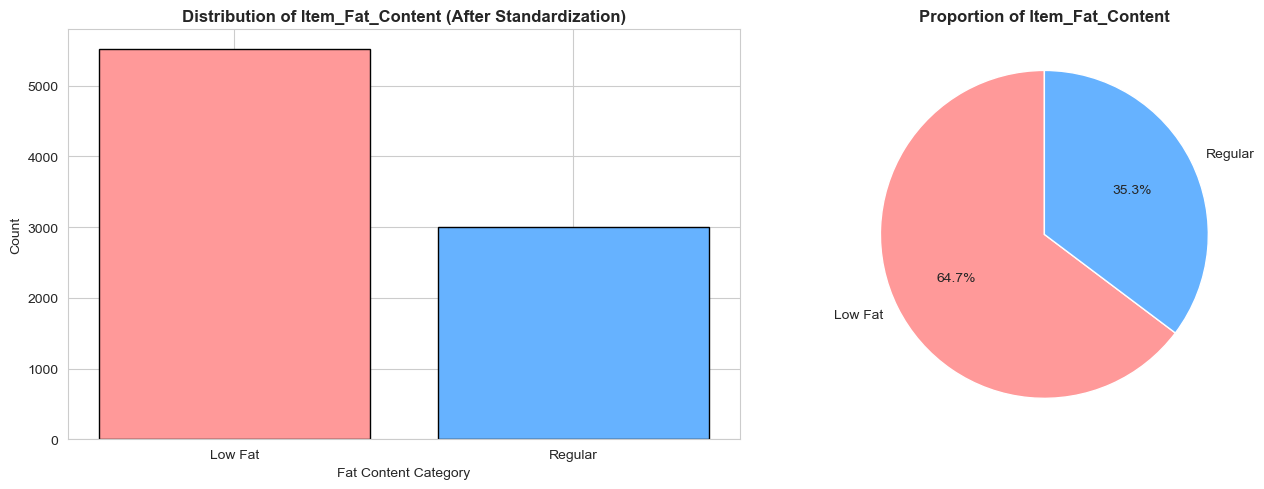

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fat_counts = df['Item_Fat_Content'].value_counts()
colors = ['#FF9999', '#66B2FF', '#99FF99']

axes[0].bar(fat_counts.index, fat_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribution of Item_Fat_Content (After Standardization)', fontweight='bold')
axes[0].set(ylabel='Count', xlabel='Fat Content Category')

axes[1].pie(fat_counts.values, labels=fat_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Proportion of Item_Fat_Content', fontweight='bold')

plt.tight_layout()
plt.show()

## 1.2 Fixing Business Logic Errors
Relabeling non-consumable items (product codes starting with **'NC'**) as **'Non-Edible'** in `Item_Fat_Content`, since household goods cannot logically have a fat content.

In [5]:
# Fix business logic: Items starting with 'NC' are Non-Consumable
df.loc[df['Item_Identifier'].str.startswith('NC'), 'Item_Fat_Content'] = 'Non-Edible'
print("--- After Fixing Logic Errors ---")
print(df['Item_Fat_Content'].value_counts())

--- After Fixing Logic Errors ---
Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64


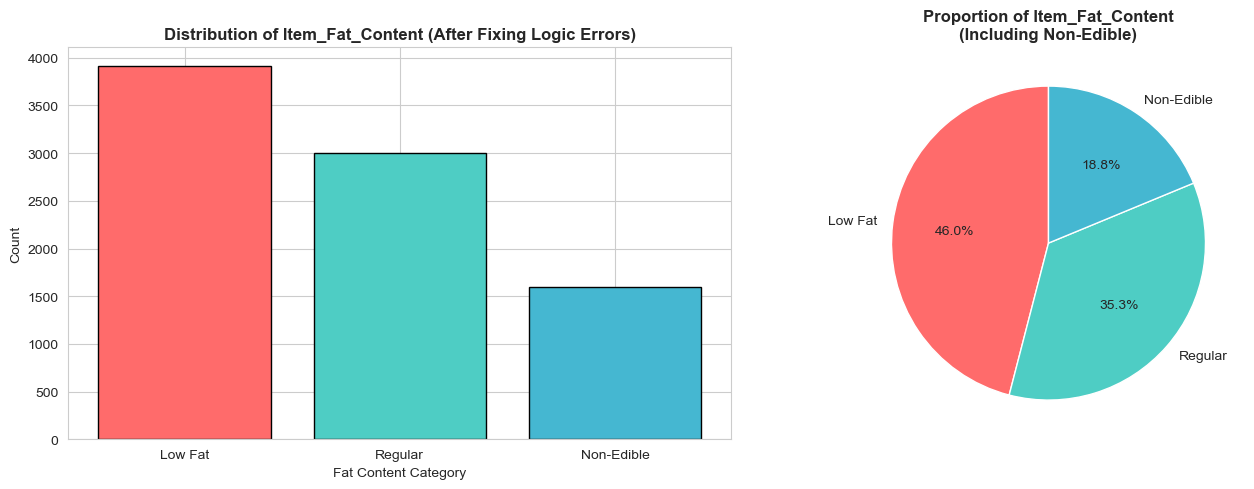

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fat_counts = df['Item_Fat_Content'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0].bar(fat_counts.index, fat_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribution of Item_Fat_Content (After Fixing Logic Errors)', fontweight='bold')
axes[0].set(ylabel='Count', xlabel='Fat Content Category')

axes[1].pie(fat_counts.values, labels=fat_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Proportion of Item_Fat_Content\n(Including Non-Edible)', fontweight='bold')

plt.tight_layout()
plt.show()

## 1.3 Handling Placeholders (The 0.0 Issue)
Replacing physically impossible `0.0` values in `Item_Visibility` with `NaN`.

In [7]:
# Check the number of 0.0 values before processing
zeros_count = (df['Item_Visibility'] == 0).sum()
print("--- Before Processing: Item_Visibility ---")
print(f"Number of 0 values: {zeros_count}")
print(f"Total NaN values in Item_Visibility: {df['Item_Visibility'].isna().sum()}")
print("-" * 40)

# Replace 0 with NaN
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)

# Verify the replacement
print("\n--- After Processing: Item_Visibility ---")
print(f"Number of 0 values: {(df['Item_Visibility'] == 0).sum()}")
print(f"Total NaN values in Item_Visibility: {df['Item_Visibility'].isna().sum()}")

--- Before Processing: Item_Visibility ---
Number of 0 values: 526
Total NaN values in Item_Visibility: 0
----------------------------------------

--- After Processing: Item_Visibility ---
Number of 0 values: 0
Total NaN values in Item_Visibility: 526


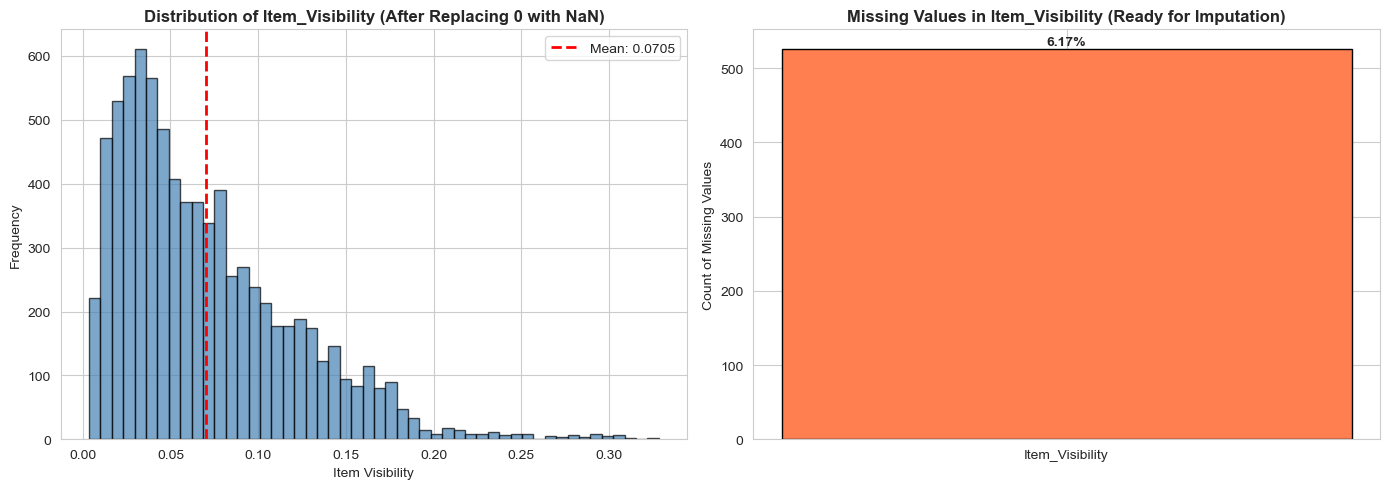

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Item_Visibility'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Item_Visibility (After Replacing 0 with NaN)', fontweight='bold')
axes[0].set(xlabel='Item Visibility', ylabel='Frequency')
mean_val = df['Item_Visibility'].mean()
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
axes[0].legend()

missing_count = df['Item_Visibility'].isna().sum()
missing_pct = (missing_count / len(df)) * 100
axes[1].bar(['Item_Visibility'], [missing_count], color='coral', edgecolor='black')
axes[1].set_title('Missing Values in Item_Visibility (Ready for Imputation)', fontweight='bold')
axes[1].set_ylabel('Count of Missing Values')
axes[1].text(0, missing_count + 5, f'{missing_pct:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 1.4 Imputation for Missing Values
Applying grouped imputation for `Item_Weight` and `Item_Visibility` using the mean of their respective `Item_Identifier`. For `Outlet_Size`, we replace missing values with a new category **'Unknown'** to preserve data integrity and prevent severe bias.

In [9]:
# Check missing values before imputation
print("--- Before Imputation: Missing Values ---")
print(df[['Item_Weight', 'Item_Visibility', 'Outlet_Size']].isnull().sum())
print("-" * 40)

# 1. Impute 'Item_Weight' with the mean weight of the same 'Item_Identifier'
df['Item_Weight'] = df['Item_Weight'].fillna(
    df.groupby('Item_Identifier')['Item_Weight'].transform('mean')
)

# 2. Impute 'Item_Visibility' with the mean visibility of the same 'Item_Identifier'
df['Item_Visibility'] = df['Item_Visibility'].fillna(
    df.groupby('Item_Identifier')['Item_Visibility'].transform('mean')
)

# 3. Impute 'Outlet_Size' with a new category 'Unknown'
df['Outlet_Size'] = df['Outlet_Size'].fillna('Unknown')

# Verify the imputation
print("\n--- After Imputation: Missing Values ---")
print(df[['Item_Weight', 'Item_Visibility', 'Outlet_Size']].isnull().sum())
print("-" * 40)

# Verify the new category in Outlet_Size
print("\nDistribution of Outlet_Size including 'Unknown':")
print(df['Outlet_Size'].value_counts())

--- Before Imputation: Missing Values ---
Item_Weight        1463
Item_Visibility     526
Outlet_Size        2410
dtype: int64
----------------------------------------

--- After Imputation: Missing Values ---
Item_Weight        4
Item_Visibility    0
Outlet_Size        0
dtype: int64
----------------------------------------

Distribution of Outlet_Size including 'Unknown':
Outlet_Size
Medium     2793
Unknown    2410
Small      2388
High        932
Name: count, dtype: int64


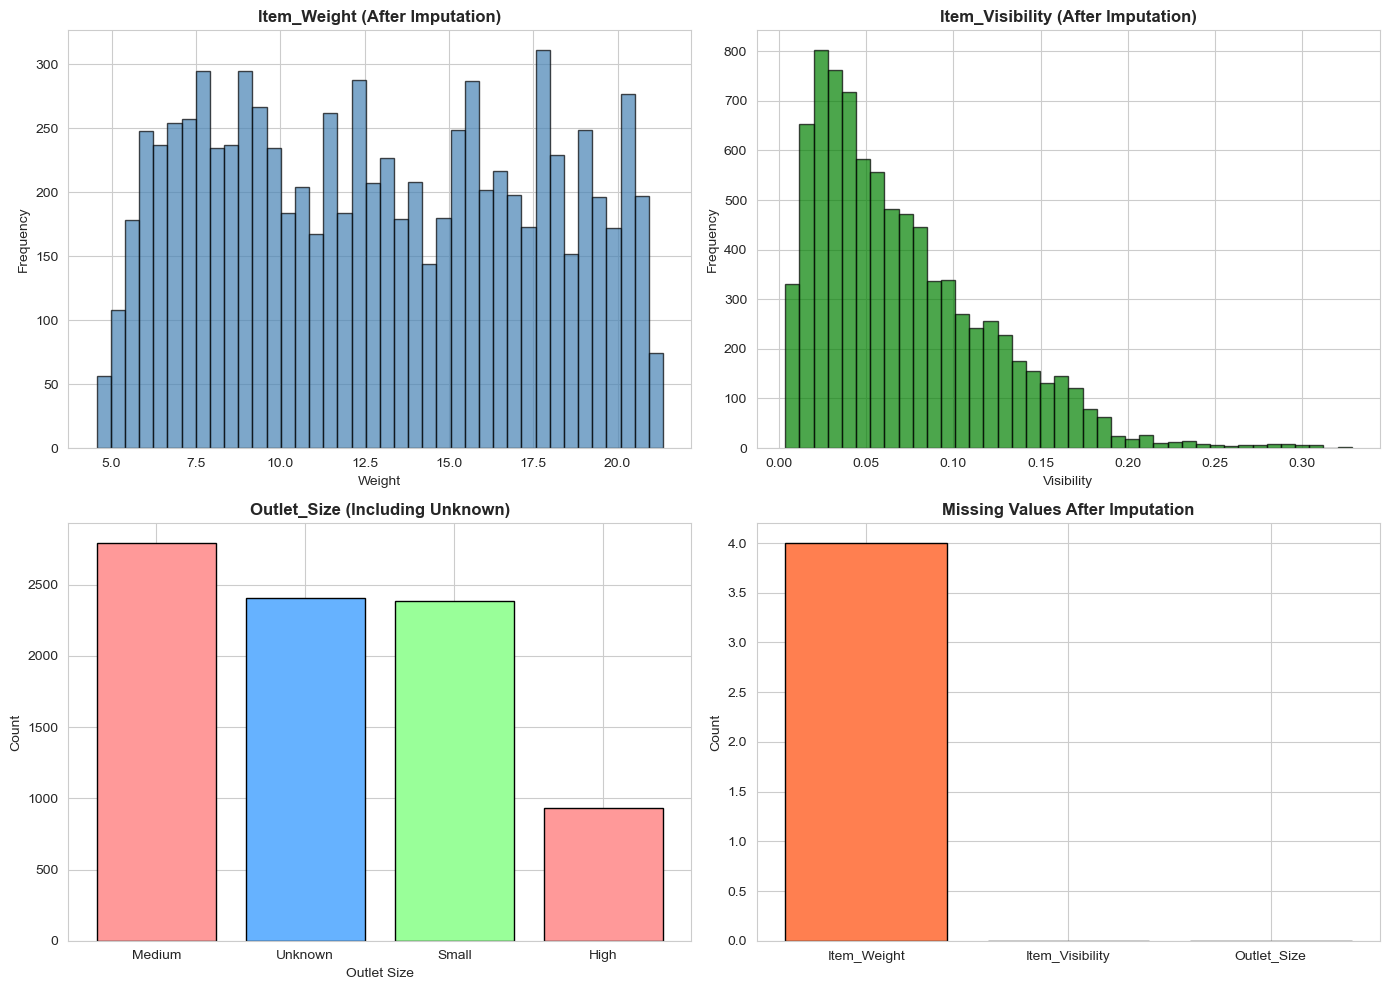

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Item_Weight'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Item_Weight (After Imputation)', fontweight='bold')
axes[0, 0].set(xlabel='Weight', ylabel='Frequency')

axes[0, 1].hist(df['Item_Visibility'], bins=40, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Item_Visibility (After Imputation)', fontweight='bold')
axes[0, 1].set(xlabel='Visibility', ylabel='Frequency')

outlet_counts = df['Outlet_Size'].value_counts()
axes[1, 0].bar(outlet_counts.index, outlet_counts.values, color=['#FF9999', '#66B2FF', '#99FF99'], edgecolor='black')
axes[1, 0].set_title('Outlet_Size (Including Unknown)', fontweight='bold')
axes[1, 0].set(ylabel='Count', xlabel='Outlet Size')

missing_counts = [df['Item_Weight'].isna().sum(), df['Item_Visibility'].isna().sum(), df['Outlet_Size'].isna().sum()]
axes[1, 1].bar(['Item_Weight', 'Item_Visibility', 'Outlet_Size'], missing_counts, color='coral', edgecolor='black')
axes[1, 1].set_title('Missing Values After Imputation', fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Investigating Residual Missing Values
After the primary imputation based on `Item_Identifier`, a few records (4 rows) remain missing for `Item_Weight`. This occurs because these specific products either appear only once in the dataset or lack weight data across all their occurrences.  

In [11]:
# Identify and display the remaining 4 rows with missing Item_Weight
residual_missing = df[df['Item_Weight'].isnull()]

print(f"Number of residual missing rows found: {len(residual_missing)}")
display(residual_missing)

Number of residual missing rows found: 4


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
927,FDN52,NaN,Regular,0.130933,Frozen Foods,86.9198,OUT027,1985,Medium,Tier 3,Supermarket Type3,1569.9564
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.0440,OUT027,1985,Medium,Tier 3,Supermarket Type3,4434.2280
4187,FDE52,NaN,Regular,0.029742,Dairy,88.9514,OUT027,1985,Medium,Tier 3,Supermarket Type3,3453.5046
5022,FDQ60,NaN,Regular,0.191501,Baking Goods,121.2098,OUT019,1985,Small,Tier 1,Grocery Store,120.5098


For the remaining 4 items where `Item_Identifier` did not have a historical weight record, we apply a fallback imputation using the **Mean** weight of their respective **`Item_Type`**. This ensures 100% data completeness without losing valuable sales observations.

In [12]:
# Apply fallback imputation for the 4 stubborn NaN values
df['Item_Weight'] = df['Item_Weight'].fillna(
    df.groupby('Item_Type')['Item_Weight'].transform('mean')
)

# Final verification to ensure 0 missing values
print("--- Final Missing Value Count ---")
print(df[['Item_Weight', 'Item_Visibility', 'Outlet_Size']].isnull().sum())

--- Final Missing Value Count ---
Item_Weight        0
Item_Visibility    0
Outlet_Size        0
dtype: int64


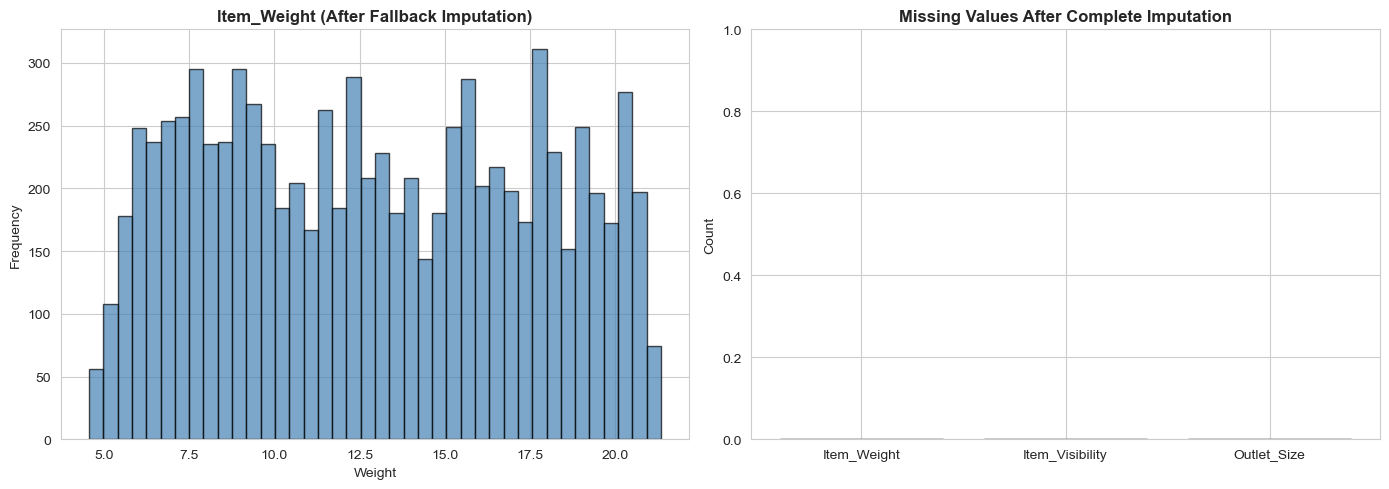

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Item_Weight'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Item_Weight (After Fallback Imputation)', fontweight='bold')
axes[0].set(xlabel='Weight', ylabel='Frequency')

missing_after_fallback = df[['Item_Weight', 'Item_Visibility', 'Outlet_Size']].isnull().sum()
axes[1].bar(missing_after_fallback.index, missing_after_fallback.values, color='green', edgecolor='black')
axes[1].set_title('Missing Values After Complete Imputation', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 1.5 Feature Engineering: Outlet Age
The `Outlet_Establishment_Year` represents the year a store was opened. However, for a predictive model, the **age of the outlet** (years of operation) is a more meaningful feature. We will calculate the outlet's age relative to the year the data was collected (2013).

In [14]:
# Calculate the age of the outlet based on the data collection year (2013)
df['Outlet_Years'] = 2013 - df['Outlet_Establishment_Year']

# Verify the new column
print("--- After Feature Engineering: Outlet_Years ---")
print(df[['Outlet_Establishment_Year', 'Outlet_Years']])
print("-" * 40)

# Check the distribution of years
print(df['Outlet_Years'].describe())

--- After Feature Engineering: Outlet_Years ---
      Outlet_Establishment_Year  Outlet_Years
0                          1999            14
1                          2009             4
2                          1999            14
3                          1998            15
4                          1987            26
...                         ...           ...
8518                       1987            26
8519                       2002            11
8520                       2004             9
8521                       2009             4
8522                       1997            16

[8523 rows x 2 columns]
----------------------------------------
count    8523.000000
mean       15.168133
std         8.371760
min         4.000000
25%         9.000000
50%        14.000000
75%        26.000000
max        28.000000
Name: Outlet_Years, dtype: float64


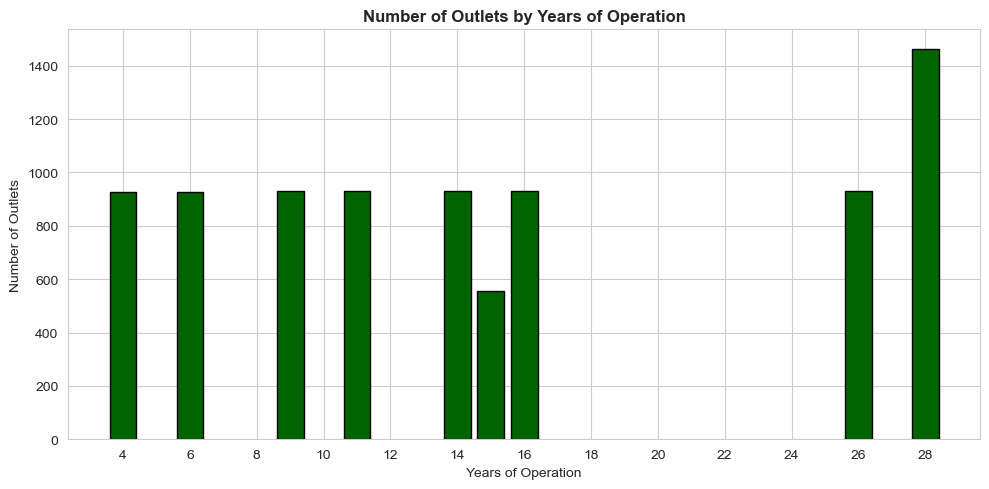

In [15]:
# Plot bar chart: Number of outlets by years of operation (x-axis step=2)
outlet_years_counts = df['Outlet_Years'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(outlet_years_counts.index, outlet_years_counts.values, color='darkgreen', edgecolor='black')
plt.title('Number of Outlets by Years of Operation', fontweight='bold')
plt.xlabel('Years of Operation')
plt.ylabel('Number of Outlets')
plt.xticks(ticks=range(int(outlet_years_counts.index.min()), int(outlet_years_counts.index.max())+1, 2))
plt.tight_layout()
plt.show()

## 1.6 Dropping Irrelevant Features
To streamline the dataset for machine learning, we remove columns that are either redundant or do not contribute predictive value:
* **`Outlet_Establishment_Year`**: Replaced by the more meaningful `Outlet_Years`.
* **`Item_Identifier`**: A unique ID with high cardinality that does not provide generalizable patterns for the model.
* **`Outlet_Identifier`**: A store-specific ID that prevents the model from generalizing to new, unseen stores. Furthermore, its inherent information is already fully captured by existing features (`Outlet_Type`, `Outlet_Size`, `Outlet_Location_Type`), making it redundant and a potential source of multicollinearity.

In [16]:
# List of columns to drop
cols_to_drop = ['Item_Identifier', 'Outlet_Establishment_Year', 'Outlet_Identifier']

# Drop the columns
df.drop(columns=cols_to_drop, inplace=True)

# Verify the final structure of the cleaned dataset
print("--- Final Columns After Cleaning ---")
print(df.columns.tolist())
print("-" * 40)
print(f"Current Shape: {df.shape}")
display(df)

--- Final Columns After Cleaning ---
['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales', 'Outlet_Years']
----------------------------------------
Current Shape: (8523, 10)


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Years
0,9.300,Low Fat,0.016047,Dairy,249.8092,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,5.920,Regular,0.019278,Soft Drinks,48.2692,Medium,Tier 3,Supermarket Type2,443.4228,4
2,17.500,Low Fat,0.016760,Meat,141.6180,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,19.200,Regular,0.022911,Fruits and Vegetables,182.0950,Unknown,Tier 3,Grocery Store,732.3800,15
4,8.930,Non-Edible,0.016164,Household,53.8614,High,Tier 3,Supermarket Type1,994.7052,26
...,...,...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,0.056783,Snack Foods,214.5218,High,Tier 3,Supermarket Type1,2778.3834,26
8519,8.380,Regular,0.046982,Baking Goods,108.1570,Unknown,Tier 2,Supermarket Type1,549.2850,11
8520,10.600,Non-Edible,0.035186,Health and Hygiene,85.1224,Small,Tier 2,Supermarket Type1,1193.1136,9
8521,7.210,Regular,0.145221,Snack Foods,103.1332,Medium,Tier 3,Supermarket Type2,1845.5976,4


# 2. Relationships & Correlation After Cleaning Data

## 2.1. Preliminary Patterns

In this section, we explore the linear relationships between the numerical variables in our dataset.

To emphasize the **strength** (magnitude) of these relationships rather than their direction (positive/negative), we will compute the **Absolute Correlation Matrix**. 

* **Methodology:** We calculate the Pearson correlation coefficients for all numerical columns and convert them to absolute values (ranging from 0 to 1).
* **Visualization:** We use a heatmap with the `viridis` color palette. Darker/brighter colors will immediately highlight the pairs of variables that have the strongest predictive relationship with each other.

=== Absolute Correlation Matrix ===


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years,Item_Outlet_Sales
Item_Weight,1.000,0.021,0.026,0.013,0.013
Item_Visibility,0.021,1.000,0.006,0.075,0.126
Item_MRP,0.026,0.006,1.000,0.005,0.568
Outlet_Years,0.013,0.075,0.005,1.000,0.049
Item_Outlet_Sales,0.013,0.126,0.568,0.049,1.000


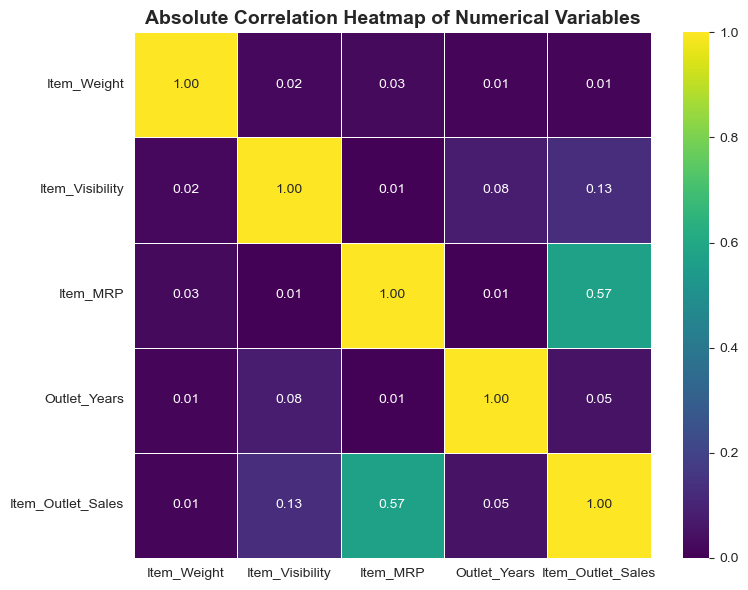

In [17]:
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years', 'Item_Outlet_Sales']

# Calculate the correlation matrix and get absolute values
corr_matrix = df[num_cols].corr()
corr_matrix_abs = corr_matrix.abs()

print("=== Absolute Correlation Matrix ===")
display(corr_matrix_abs.round(3))

# Create a heatmap using the viridis palette
plt.figure(figsize=(8, 6))
# Set vmin=0 since absolute correlation values range from 0 to 1
sns.heatmap(corr_matrix_abs, annot=True, cmap='viridis', fmt=".2f", vmin=0, vmax=1, linewidths=0.5)
plt.title('Absolute Correlation Heatmap of Numerical Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

**Correlation Analysis Conclusion**
- `Item_MRP` **is the strongest predictor**: The variable `Item_MRP` (Maximum Retail Price) shows a moderate positive correlation with `Item_Outlet_Sales` (coefficient of **0.568**). This aligns with business logic: higher-priced items tend to generate higher total sales revenue. This is undoubtedly the most important feature among the numerical variables.
- **Other numerical features have a very weak impact**: Variables such as `Item_Weight` (0.013), `Outlet_Years` (0.049), and `Item_Visibility` (0.126) have correlation coefficients very close to 0. This indicates that they have almost no direct linear relationship with the target variable (sales).
- **No Multicollinearity**: The cross-correlation between the independent variables themselves (e.g., between `Item_Weight` and `Item_Visibility` is 0.021) is extremely low. This is an excellent sign, as it proves there is no overlapping information between features, ensuring that the Linear Regression algorithm will remain stable and unbiased.

## 2.2. Frequency Heatmaps

### 2.2.1. Categorical x Categorical

1. Categorical x Categorical: ALL Frequency Plots (with counts):



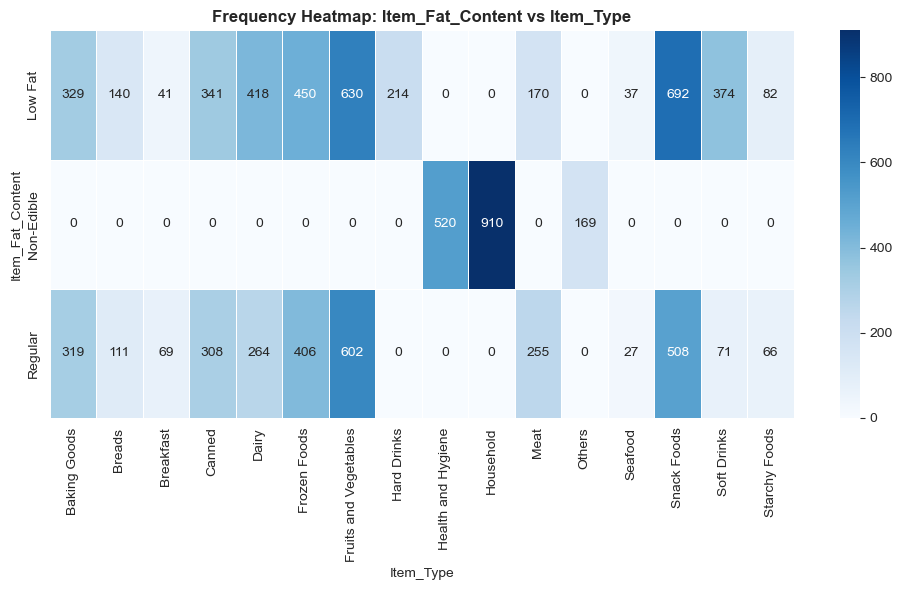

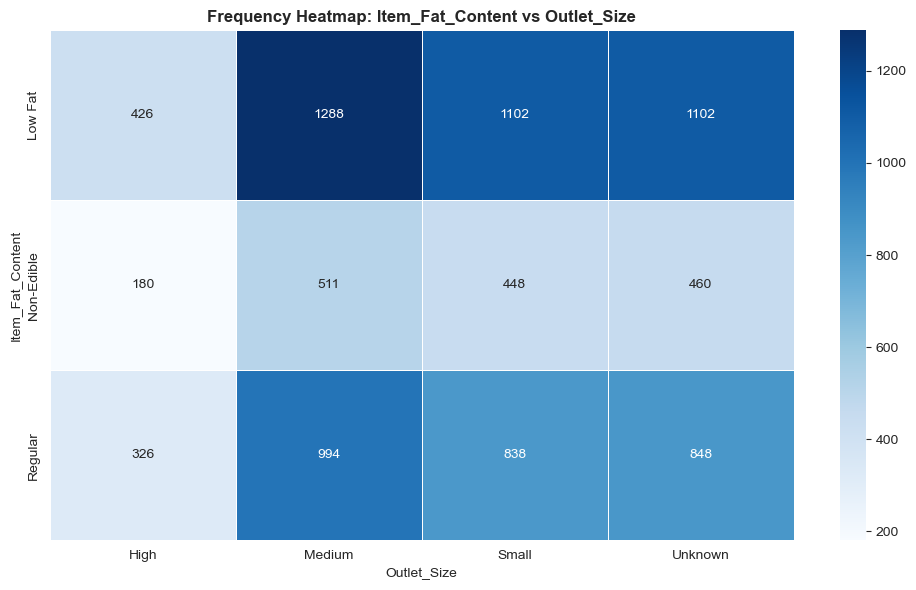

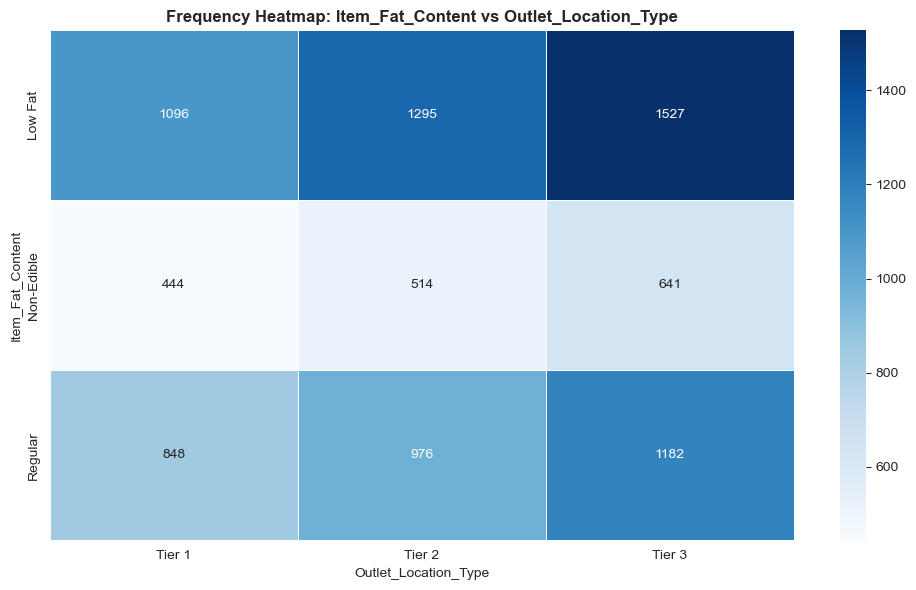

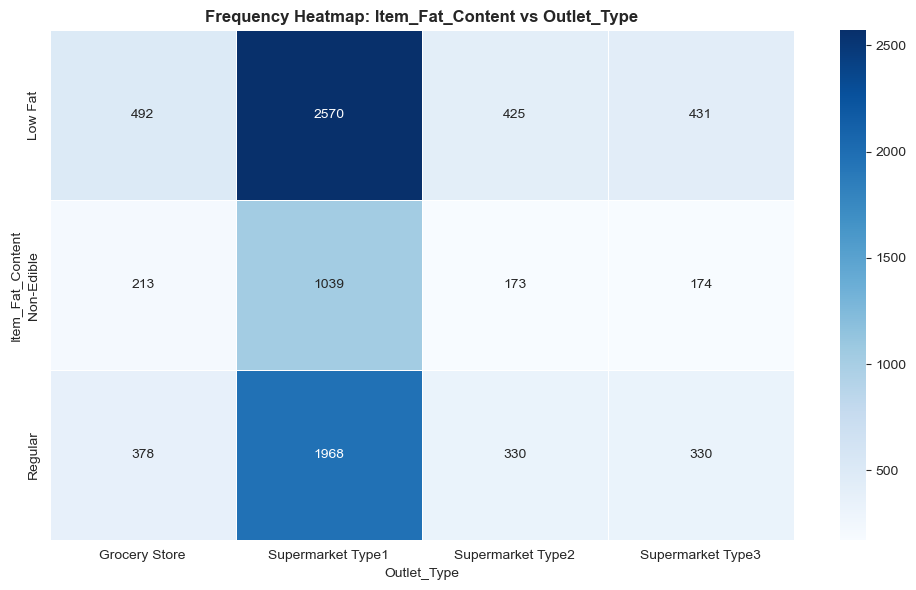

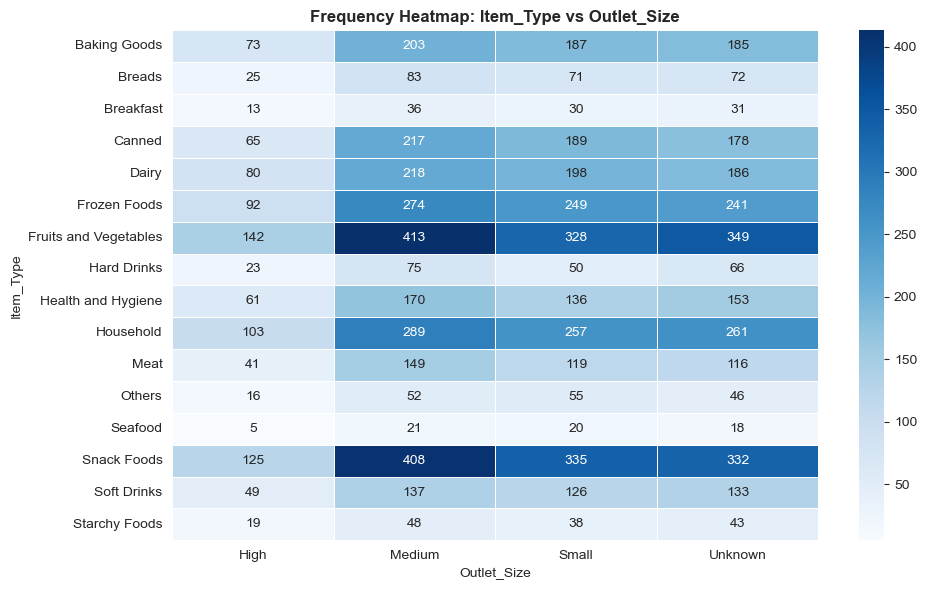

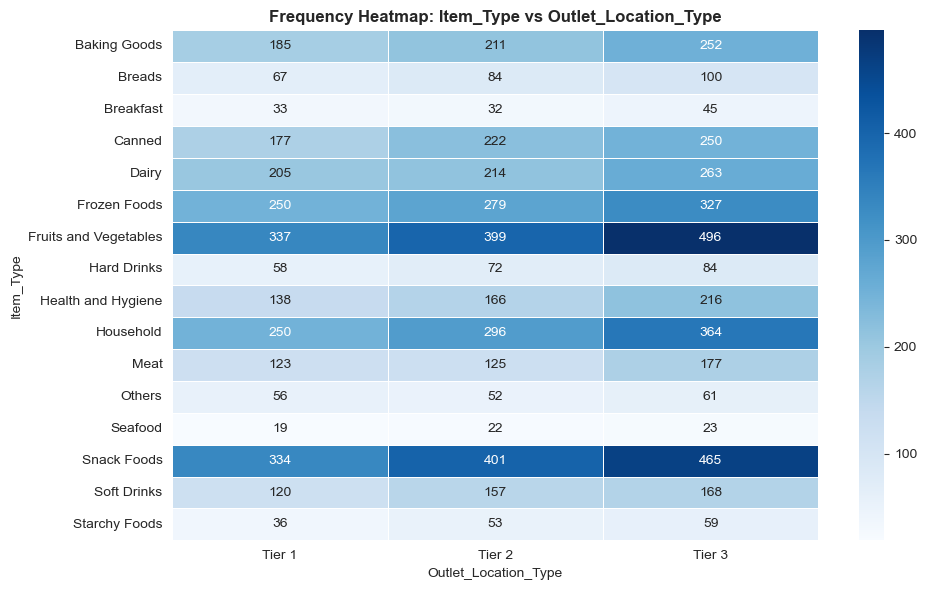

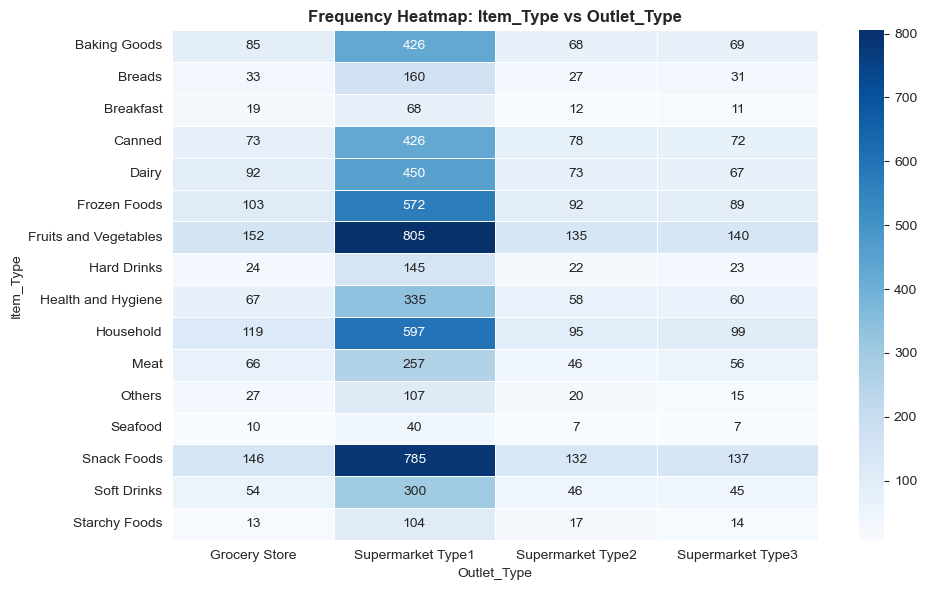

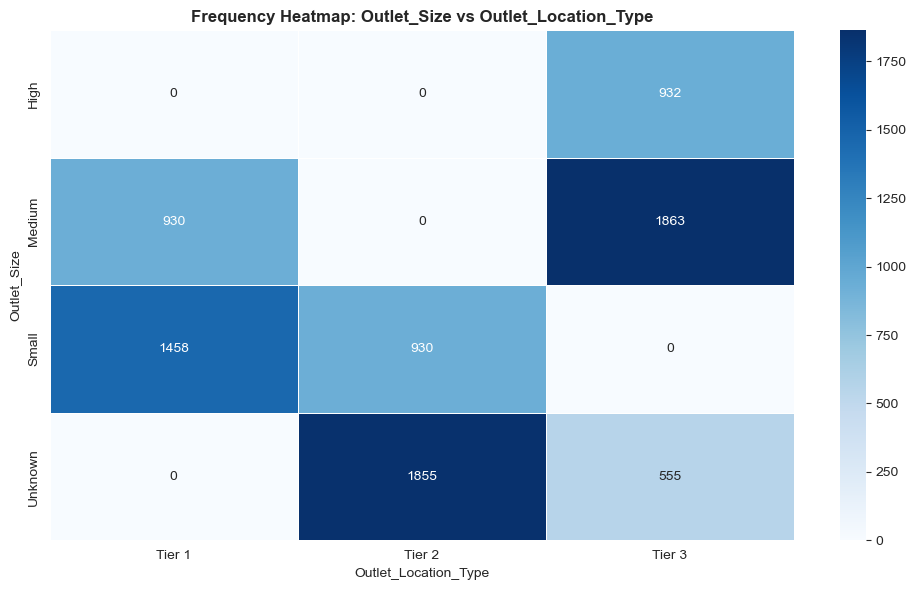

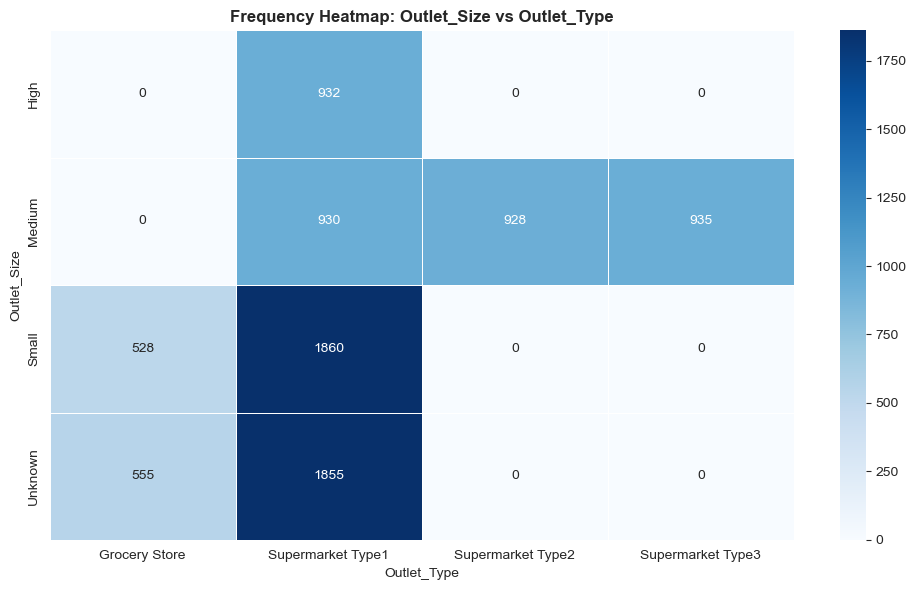

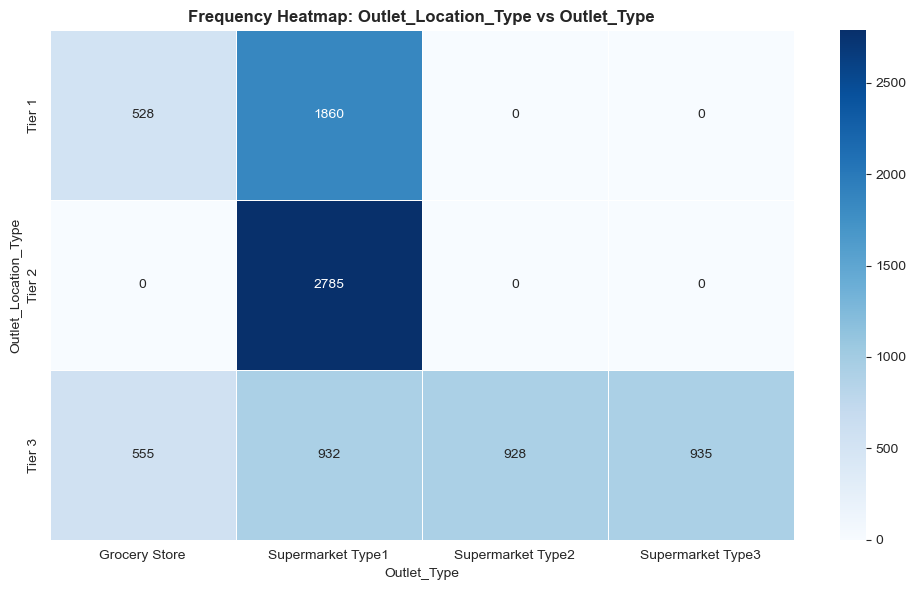

In [18]:
# List of important categorical variables (Excluding Item_Identifier as it has 1559 unique values)
cat_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

print("1. Categorical x Categorical: ALL Frequency Plots (with counts):\n")
# Create all possible combinations of 2 columns from the cat_cols list
all_cat_pairs = list(itertools.combinations(cat_cols, 2))



for col1, col2 in all_cat_pairs:
    plt.figure(figsize=(10, 6))
    cross_tab = pd.crosstab(df[col1], df[col2])
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=0.5)
    plt.title(f'Frequency Heatmap: {col1} vs {col2}', fontweight='bold')
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.tight_layout()
    plt.show()




**Frequency Heatmap Analysis Conclusion** 

**1. Item Features (Product Distribution)**  
The heatmaps involving `Item_Type` and `Item_Fat_Content` reveal a very clear pattern: Products are distributed extremely evenly across the entire retail network.

- **High Independence**: Regardless of an outlet's location (Tier 1, 2, 3), size, or type, the proportion of item categories on the shelves remains remarkably consistent. This indicates that the retail chain applies a standardized Product Portfolio strategy across all its branches.

- **Dominant Categories**: **Fruits and Vegetables** and **Snack Foods** are the most heavily stocked items across all scenarios.

- **Data Integrity Confirmed**: The `Item_Fat_Content` column, after introducing the **Non-Edible** category, works flawlessly. The **Non-Edible** group maps exclusively to **Health and Hygiene**, **Household**, and **Others** items (as seen in the first heatmap).

**2. Outlet Features (Strong Internal Correlations)**  
Unlike the products, the characteristics of the stores themselves (`Outlet_Size`, `Outlet_Location_Type`, `Outlet_Type`) are strictly correlated and follow clear structural rules.

- **The Supermarket Type 2 & 3 Rule**: 100% of `Supermarket Type2` and `Supermarket Type3` outlets are standardized as `Medium` size and are exclusively located in `Tier 3` areas.

- **The Tier 2 Monopoly**: The `Tier 2` location is completely dominated by a single business model: `Supermarket Type1` (2,785 stores). There are absolutely no Grocery Stores or Supermarket Type 2/3 in this tier.

- **Size Distribution by Location**: The largest supermarkets (`High` size) exist solely in `Tier 3`. Meanwhile, `Tier 1` focuses exclusively on `Small` and `Medium` sized stores.

- **The Grocery Store Model**: `Grocery Stores` are exclusively categorized as `Small` or have missing size data (`Unknown`). There are absolutely no Medium or High-sized Grocery Stores.

**3. Crucial Clues for Missing Data (Unknown Outlet Size)**  
The cross-heatmaps between `Outlet_Size`, `Location`, and `Type` pinpoint the exact origins of the "Unknown" values:

- The largest `Unknown` cluster (1,855 rows) is located entirely in Tier 2, and they are all `Supermarket Type1`.

- The remaining `Unknown` cluster (555 rows) is located entirely in `Tier 3`, and they are all `Grocery Stores`.

### 2.2.2. Numerical x Categorical


Numerical x Categorical: Sales Summary by ALL Categories (using boxplots):



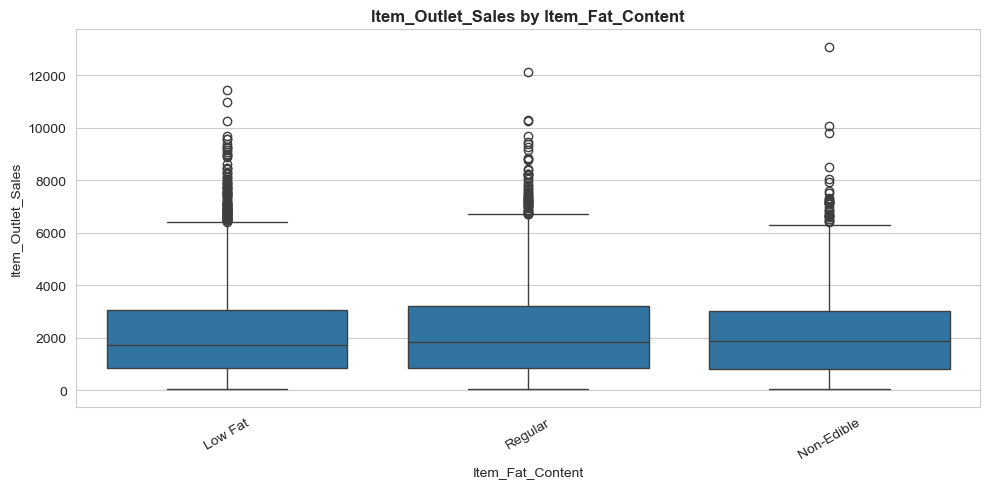

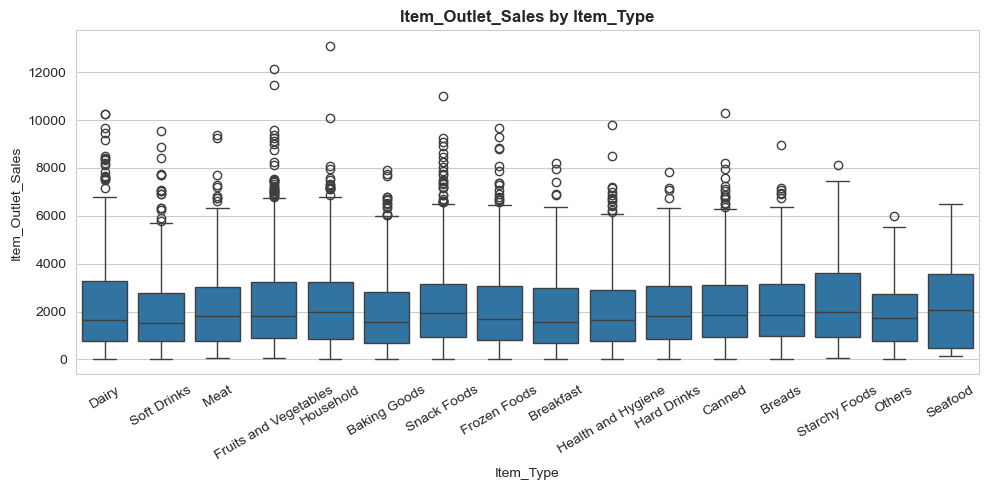

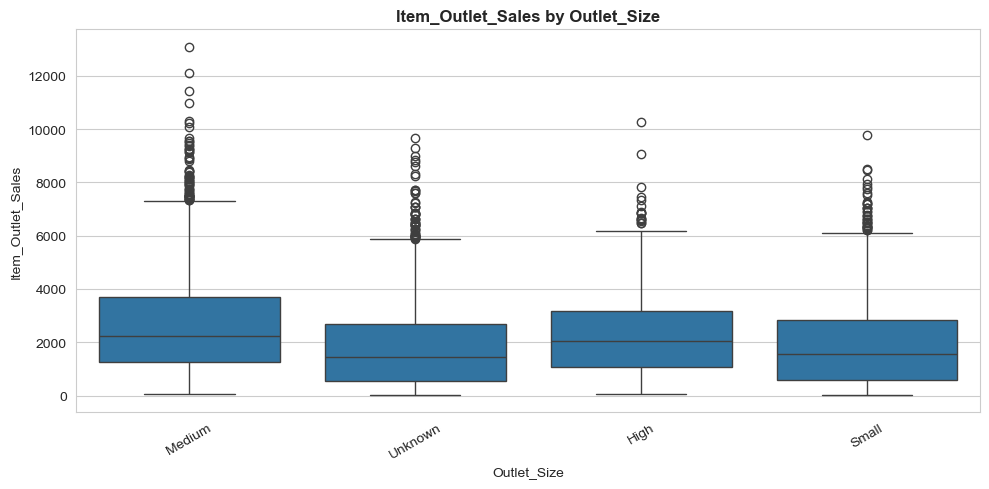

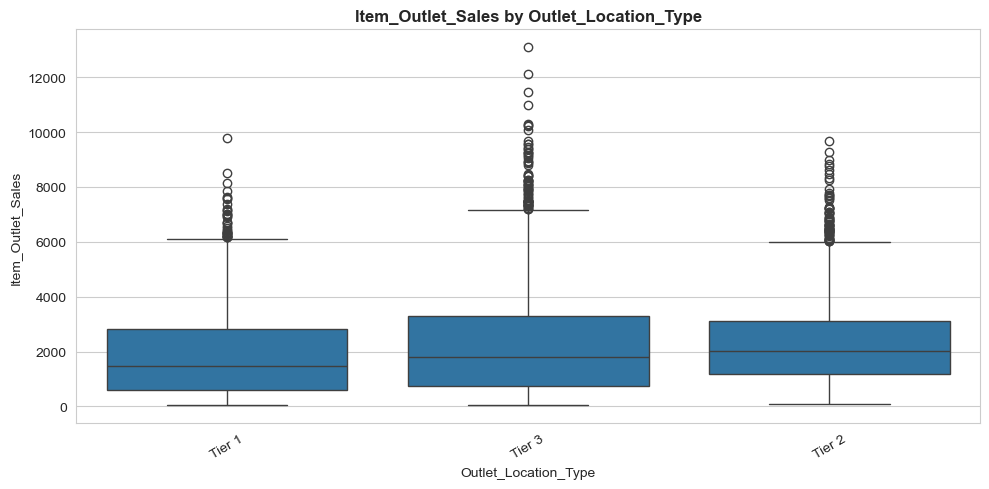

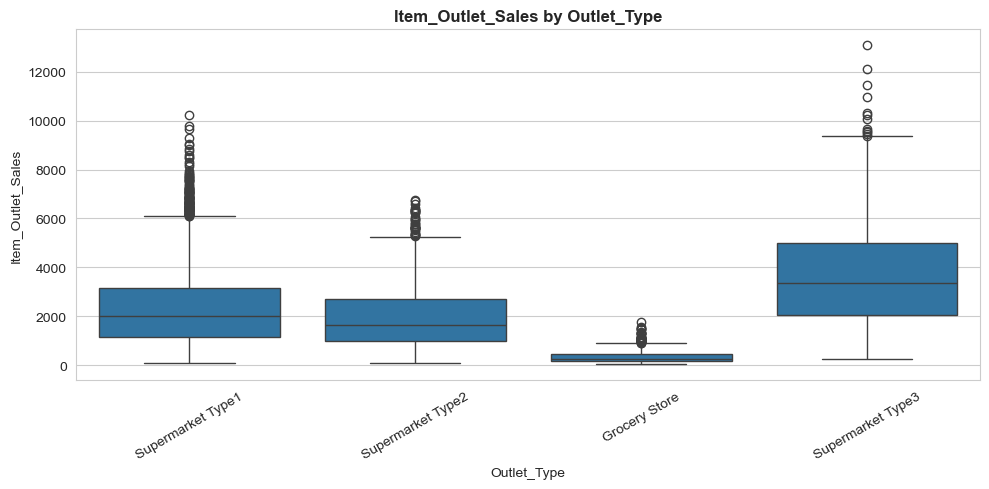

In [19]:
print("\nNumerical x Categorical: Sales Summary by ALL Categories (using boxplots):\n")

# Boxplots for Item_Outlet_Sales by each categorical variable
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='Item_Outlet_Sales', data=df)
    plt.title(f'Item_Outlet_Sales by {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Item_Outlet_Sales')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

**Boxplot Analysis Conclusion**

1. Product Features (Low Impact):

- Variables like `Item_Fat_Content` and `Item_Type` show nearly identical median sales distributions across all categories.

- **Conclusion**: No single item category creates a significant spike in sales. These variables will likely contribute very little to the model's predictive power.

2. Outlet Features (The Deciding Factors):

- `Outlet_Type` **(Most Important)** `Supermarket Type3` is the most outstanding business model, generating the highest revenue in the system. Conversely, `Grocery Stores` have rock-bottom sales.

- `Location` & `Size` **(Ripple Effect)**: `Tier 3` locations and `Medium` size outlets show the highest sales. The simple reason is that all top-performing stores (`Supermarket Type3`) fall strictly into these two categories (as proven by the previous Heatmaps).

# 3. Dataset Splitting (Train-Test Split)
* **Description**: We split the dataset into two independent sets: **Training (80%)** and **Testing (20%)** using `train_test_split`.

* **Reasoning**: Splitting the data before any transformations (like Scaling or Log) is the best practice to prevent **Data Leakage**. This ensures that the test set remains completely unseen, allowing us to evaluate the model's performance on truly "new" data.

In [20]:
# Define Features (X) and Target (y)
# We use the raw cleaned data before scaling/log transformation
X = df.drop(columns=['Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the split
print(f"Dataset successfully split:")
print(f"- Training samples: {X_train.shape[0]}")
print(f"- Testing samples:  {X_test.shape[0]}")

Dataset successfully split:
- Training samples: 6818
- Testing samples:  1705


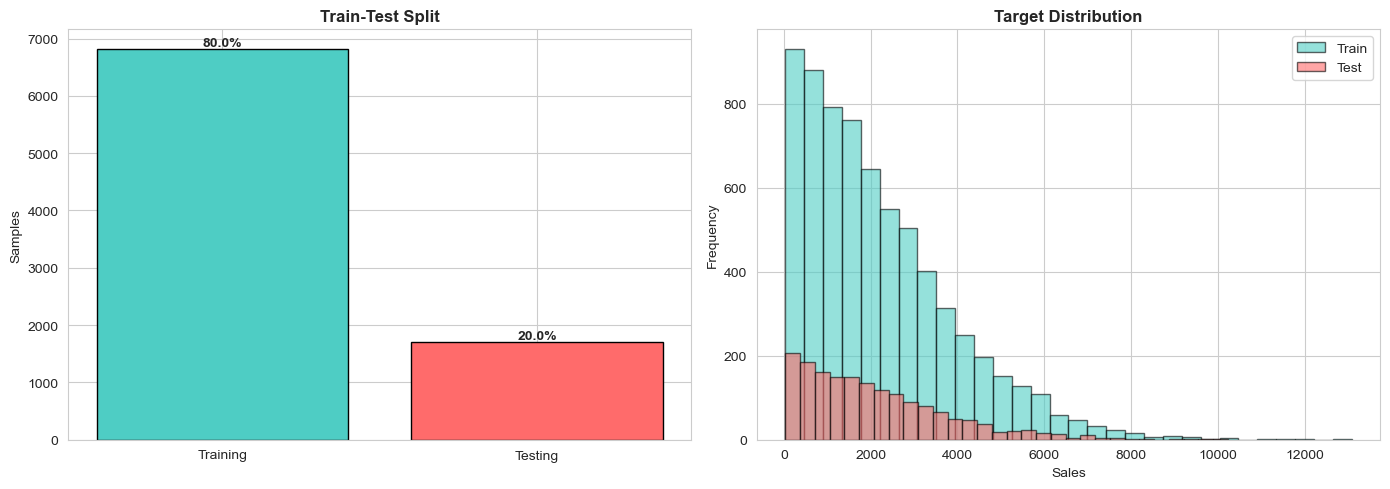

Splitting Complete: Train 6818 | Test 1705


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_size, test_size = X_train.shape[0], X_test.shape[0]
axes[0].bar(['Training', 'Testing'], [train_size, test_size], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[0].set_title('Train-Test Split', fontweight='bold')
axes[0].set_ylabel('Samples')
for i, v in enumerate([train_size, test_size]):
    pct = (v / (train_size + test_size)) * 100
    axes[0].text(i, v + 50, f'{pct:.1f}%', ha='center', fontweight='bold')

axes[1].hist(y_train, bins=30, alpha=0.6, label='Train', color='#4ECDC4', edgecolor='black')
axes[1].hist(y_test, bins=30, alpha=0.6, label='Test', color='#FF6B6B', edgecolor='black')
axes[1].set_title('Target Distribution', fontweight='bold')
axes[1].set(xlabel='Sales', ylabel='Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Splitting Complete: Train {X_train.shape[0]} | Test {X_test.shape[0]}")

**Saving Processed Data**

In [22]:
# Save X_train, y_train, X_test, y_test to separate CSV files
X_train.to_csv('../data/train_data/X_train.csv', index=False)
y_train.to_csv('../data/train_data/y_train.csv', index=False)
X_test.to_csv('../data/test_data/X_test.csv', index=False)
y_test.to_csv('../data/test_data/y_test.csv', index=False)

# (Optional) Still save the combined files if needed
train_processed = pd.concat([X_train, y_train], axis=1)
test_processed = pd.concat([X_test, y_test], axis=1)
train_processed.to_csv('../data/train_data/train.csv', index=False)
test_processed.to_csv('../data/test_data/test.csv', index=False)

print("Processed data successfully saved to data folder.\n")

Processed data successfully saved to data folder.

